In [1]:
# Filepath imports
# Making sure filepath runs smoothly
import sys
import os

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled
env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/bin/python
R libPaths now:
[1] "/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/R/library"

phyloseq installed? True


In [2]:
# imports for data analysis

# data analysis
import pandas as pd
import numpy as np
import json

# qiime and related
import qiime2
from qiime2 import Metadata, Artifact
import biom

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

from scipy.interpolate import UnivariateSpline

In [5]:
# On clr data
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_val['age_bin']=pd.cut(
    abs_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_val['age_bin']=pd.cut(
    rel_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']

# Trying a CLR transformation
import numpy as np
import pandas as pd

def clr_dataframe(df, pseudocount=1e-6):
    """
    Apply CLR transformation to a DataFrame
    where rows = samples and columns = taxa.
    
    Parameters
    ----------
    df : pd.DataFrame
        Compositional data (must be non-negative).
    pseudocount : float
        Value added to avoid log(0).
        
    Returns
    -------
    pd.DataFrame
        CLR-transformed DataFrame.
    """
    
    # Add pseudocount
    df = df + pseudocount
    
    # Take log
    log_df = np.log(df)
    
    # Subtract row-wise mean (log geometric mean)
    clr_df = log_df.sub(log_df.mean(axis=1), axis=0)
    
    return clr_df

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_clr = abs_X_train.copy()
abs_X_train_clr = clr_dataframe(abs_X_train_clr)

abs_X_test_clr = abs_X_test.copy()
abs_X_test_clr = clr_dataframe(abs_X_test_clr)

abs_X_val_clr = abs_X_val.copy()
abs_X_val_clr = clr_dataframe(abs_X_val_clr)

# Relative abundance data
rel_X_train_clr = rel_X_train.copy()
rel_X_train_clr = clr_dataframe(rel_X_train_clr)

rel_X_test_clr = rel_X_test.copy()
rel_X_test_clr = clr_dataframe(rel_X_test_clr)

rel_X_val_clr = rel_X_val.copy()
rel_X_val_clr = clr_dataframe(rel_X_val_clr)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_clr.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_clr.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_clr.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_clr.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_clr.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_clr.values,   rel_val_sex])

/tmp/ipykernel_1321/106761391.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/106761391.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [7]:
# Need to edit this
abs_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_reg.fit(abs_X_train_aug, abs_Y_train)

val_preds = abs_rf_reg.predict(abs_X_val_aug)

mae = mean_absolute_error(abs_Y_val, val_preds)
rmse = mean_squared_error(abs_Y_val, val_preds, squared=False)
r2 = r2_score(abs_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 11.630860892388451
RMSE (years): 13.892996695560399
R²: 0.2636555354403073


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [11]:
# Need to edit this
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train_aug, rel_Y_train)

val_preds = rel_rf_reg.predict(rel_X_val_aug)

mae = mean_absolute_error(rel_Y_val, val_preds)
rmse = mean_squared_error(rel_Y_val, val_preds, squared=False)
r2 = r2_score(rel_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 11.47168503937008
RMSE (years): 13.734215785933799
R²: 0.28039048913542597


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [12]:
# We try with log
# On clr data
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_val['age_bin']=pd.cut(
    abs_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_val['age_bin']=pd.cut(
    rel_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']


# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_log.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_log.values,   rel_val_sex])

/tmp/ipykernel_1321/826810589.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/826810589.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [13]:
# Need to edit this
abs_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_reg.fit(abs_X_train_aug, abs_Y_train)

val_preds = abs_rf_reg.predict(abs_X_val_aug)

mae = mean_absolute_error(abs_Y_val, val_preds)
rmse = mean_squared_error(abs_Y_val, val_preds, squared=False)
r2 = r2_score(abs_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 11.767889763779529
RMSE (years): 13.964814974439912
R²: 0.25602295917192763


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
# Need to edit this
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train_aug, rel_Y_train)

val_preds = rel_rf_reg.predict(rel_X_val_aug)

mae = mean_absolute_error(rel_Y_val, val_preds)
rmse = mean_squared_error(rel_Y_val, val_preds, squared=False)
r2 = r2_score(rel_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 11.377406824146982
RMSE (years): 13.604622634434659
R²: 0.2939065852394216


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [15]:
# Final rf regressor
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Combining train + validation
abs_train = pd.concat([abs_train, abs_val])
rel_train = pd.concat([rel_train, rel_val])

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

# Trying a log transformation again
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])

/tmp/ipykernel_1321/771429618.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/771429618.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [27]:
# Need to edit this
abs_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_reg.fit(abs_X_train_aug, abs_Y_train)

abs_val_preds = abs_rf_reg.predict(abs_X_test_aug)

mae = mean_absolute_error(abs_Y_test, abs_val_preds)
rmse = mean_squared_error(abs_Y_test, abs_val_preds, squared=False)
r2 = r2_score(abs_Y_test, abs_val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 11.456635170603674
RMSE (years): 13.537560934784084
R²: 0.30084238998265755


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
# Need to edit this
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train_aug, rel_Y_train)

rel_val_preds = rel_rf_reg.predict(rel_X_test_aug)

mae = mean_absolute_error(rel_Y_test, rel_val_preds)
rmse = mean_squared_error(rel_Y_test, rel_val_preds, squared=False)
r2 = r2_score(rel_Y_test, rel_val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 11.375154855643045
RMSE (years): 13.47616981873474
R²: 0.30716919333020265


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


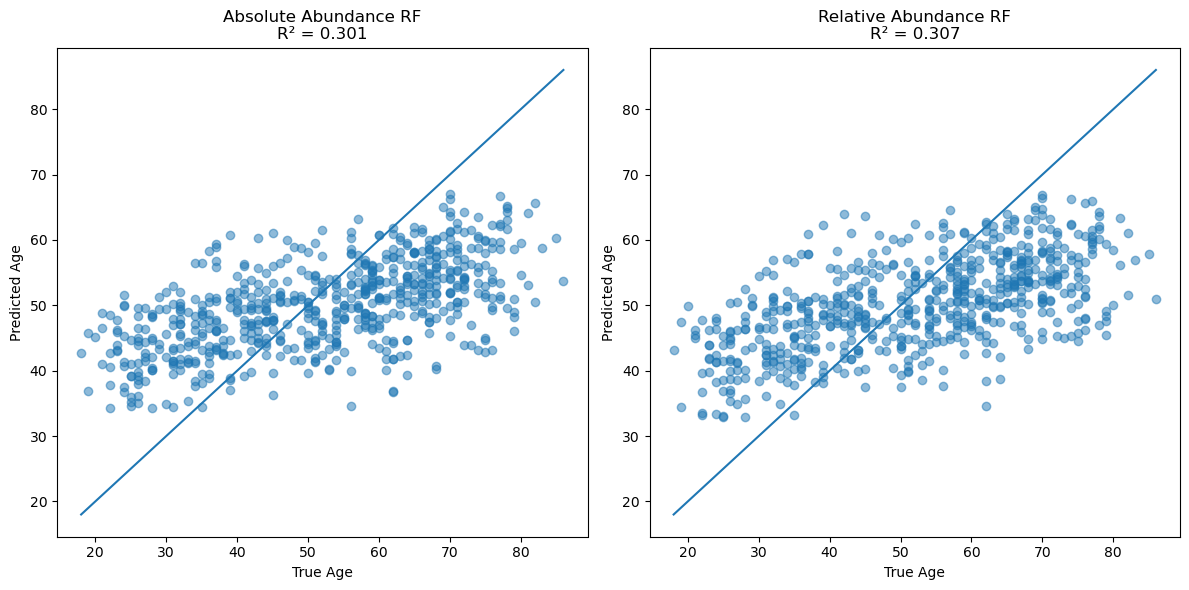

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Compute R²
r2_abs = r2_score(abs_Y_test, abs_val_preds)
r2_rel = r2_score(rel_Y_test, rel_val_preds)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Common line limits
min_val = min(abs_Y_test.min(), rel_Y_test.min())
max_val = max(abs_Y_test.max(), rel_Y_test.max())
x_line = np.linspace(min_val, max_val, 100)

# -------- Absolute --------
axes[0].scatter(abs_Y_test, abs_val_preds, alpha=0.5)
axes[0].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[0].set_title(f"Absolute Abundance RF\nR² = {r2_abs:.3f}")
axes[0].set_xlabel("True Age")
axes[0].set_ylabel("Predicted Age")

# -------- Relative --------
axes[1].scatter(rel_Y_test, rel_val_preds, alpha=0.5)
axes[1].plot(x_line, x_line)  # 1:1 perfect prediction line
axes[1].set_title(f"Relative Abundance RF\nR² = {r2_rel:.3f}")
axes[1].set_xlabel("True Age")
axes[1].set_ylabel("Predicted Age")

plt.tight_layout()
plt.show()

In [31]:
# Bootstrapping to see if differences are due to chance
n_boot = 5000
rng = np.random.default_rng(42)

diffs = []

n = len(abs_Y_test)

for _ in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    
    y_sample = abs_Y_test.iloc[idx]
    abs_sample = abs_val_preds[idx]
    rel_sample = rel_val_preds[idx]
    
    r2_abs = r2_score(y_sample, abs_sample)
    r2_rel = r2_score(y_sample, rel_sample)
    
    diffs.append(r2_rel - r2_abs)

diffs = np.array(diffs)

ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
mean_diff = diffs.mean()

print("Mean ΔR²:", mean_diff)
print("95% CI:", ci_lower, "to", ci_upper)

Mean ΔR²: 0.006129841185292379
95% CI: -0.016762765142793675 to 0.029024017526321895


In [32]:
p_value = np.mean(diffs <= 0)
print("P-value:", p_value)

P-value: 0.2994


# We try Gradient Boosting

In [39]:
# We try with log
# On clr data
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_val['age_bin']=pd.cut(
    abs_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_val['age_bin']=pd.cut(
    rel_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']


# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_log.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_log.values,   rel_val_sex])

/tmp/ipykernel_1321/826810589.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/826810589.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [40]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize model
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Fit
abs_gbr = gbr.fit(abs_X_train_aug, abs_Y_train)

# Predict
y_pred = abs_gbr.predict(abs_X_val_aug)

# Evaluate
r2 = r2_score(abs_Y_val, y_pred)
rmse = np.sqrt(mean_squared_error(abs_Y_val, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.3670506458795798
RMSE: 12.880712883917758


In [41]:
# Fit
rel_gbr = gbr.fit(rel_X_train_aug, rel_Y_train)

# Predict
y_pred = rel_gbr.predict(rel_X_val_aug)

# Evaluate
r2 = r2_score(rel_Y_val, y_pred)
rmse = np.sqrt(mean_squared_error(rel_Y_val, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.40646326062088134
RMSE: 12.473238384101794


In [42]:
# Final evaluation of Gradient Boosted Model
# Final rf regressor
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Combining train + validation
abs_train = pd.concat([abs_train, abs_val])
rel_train = pd.concat([rel_train, rel_val])

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

# Trying a log transformation again
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])

/tmp/ipykernel_1321/4108013124.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/4108013124.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [44]:
# Fit
abs_gbr = gbr.fit(abs_X_train_aug, abs_Y_train)

# Predict
y_pred = abs_gbr.predict(abs_X_test_aug)

# Evaluate
r2 = r2_score(abs_Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(abs_Y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.37927247837706324
RMSE: 12.755673097880734


In [45]:
# Fit
rel_gbr = gbr.fit(rel_X_train_aug, rel_Y_train)

# Predict
y_pred = rel_gbr.predict(rel_X_test_aug)

# Evaluate
r2 = r2_score(rel_Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(rel_Y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.39761332771357516
RMSE: 12.565811981536061


# We try an SVM RBF

In [47]:
# We try with log
# On clr data
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_val = abs_val[abs_val["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_val = rel_val[rel_val["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

abs_val['age_bin']=pd.cut(
    abs_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_val['age_bin']=pd.cut(
    rel_val['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']


# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_log.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_log.values,   rel_val_sex])

/tmp/ipykernel_1321/826810589.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/826810589.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [49]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

# ----------------------------
# Build Pipeline
# ----------------------------
# IMPORTANT: SVM requires scaling
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

# ----------------------------
# Hyperparameter Grid
# ----------------------------
param_grid = {
    "svr__C": [0.1, 1, 10, 100],
    "svr__gamma": ["scale", 0.01, 0.1, 1],
    "svr__epsilon": [0.01, 0.1, 0.5]
}

# ----------------------------
# Grid Search
# ----------------------------
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search.fit(abs_X_train_aug, abs_Y_train)

# ----------------------------
# Best Model
# ----------------------------
abs_best_svr = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# ----------------------------
# Evaluate on Test Set
# ----------------------------
y_pred = abs_best_svr.predict(abs_X_val_aug)

r2 = r2_score(abs_Y_val, y_pred)
rmse = np.sqrt(mean_squared_error(abs_Y_val, y_pred))

print("Test R²:", r2)
print("Test RMSE:", rmse)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'svr__C': 100, 'svr__epsilon': 0.5, 'svr__gamma': 'scale'}
Best CV R²: -10.151596102247106
Test R²: 0.4199336354739983
Test RMSE: 12.330885382095932


In [50]:
# Fit
grid_search.fit(rel_X_train_aug, rel_Y_train)

# ----------------------------
# Best Model
# ----------------------------
rel_best_svr = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# ----------------------------
# Evaluate on Test Set
# ----------------------------
y_pred = rel_best_svr.predict(rel_X_val_aug)

r2 = r2_score(rel_Y_val, y_pred)
rmse = np.sqrt(mean_squared_error(rel_Y_val, y_pred))

print("Test R²:", r2)
print("Test RMSE:", rmse)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
Best CV R²: -9.404549633424827
Test R²: 0.505460471043957
Test RMSE: 11.385600067662565


In [51]:
# Final evaluation
# Final evaluation of Gradient Boosted Model
# Final rf regressor
# Preprocessing train/test/val datasets
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', low_memory=False)
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv', low_memory=False)
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv', low_memory=False)

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv', low_memory=False)
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv', low_memory=False)
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv', low_memory=False)

# Combining train + validation
abs_train = pd.concat([abs_train, abs_val])
rel_train = pd.concat([rel_train, rel_val])

# Stratifying by gender
abs_train = abs_train[abs_train["sex"].isin(['male', 'female'])].copy()
abs_test = abs_test[abs_test["sex"].isin(['male', 'female'])].copy()

rel_train = rel_train[rel_train["sex"].isin(['male', 'female'])].copy()
rel_test = rel_test[rel_test["sex"].isin(['male', 'female'])].copy()

# Creating the age bin
bins = [18,30,40,50,60,70,100]
abs_train['age_bin'] = pd.cut(
    abs_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

abs_test['age_bin']=pd.cut(
    abs_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

rel_train['age_bin'] = pd.cut(
    rel_train['age'],
    bins=bins,
    right=False,
    include_lowest=True
).astype(str)

rel_test['age_bin']=pd.cut(
    rel_test['age'],
    bins=bins,  
    right=False,
    include_lowest=True
).astype(str)

# Balancing the training set
# Absolute quant
target_n = 329

abs_balanced_train = (
    abs_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Relative quant
rel_balanced_train = (
    rel_train
    .groupby("age_bin", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_n),
        random_state=42
    ))
)

# Splitting into features and targets
# Absolute quant data
abs_X_train = abs_balanced_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

# Relative abundance data
rel_X_train = rel_balanced_train[rel_balanced_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

# Trying a log transformation again
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])

/tmp/ipykernel_1321/3284468641.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1321/3284468641.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [53]:
# Fit
grid_search.fit(abs_X_train_aug, abs_Y_train)

# ----------------------------
# Best Model
# ----------------------------
abs_best_svr = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# ----------------------------
# Evaluate on Test Set
# ----------------------------
y_pred = abs_best_svr.predict(abs_X_test_aug)

r2 = r2_score(abs_Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(abs_Y_test, y_pred))

print("Test R²:", r2)
print("Test RMSE:", rmse)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
Best CV R²: -9.368544176275524
Test R²: 0.43845201309014414
Test RMSE: 12.132388738396697


In [54]:
# Fit
grid_search.fit(rel_X_train_aug, rel_Y_train)

# ----------------------------
# Best Model
# ----------------------------
rel_best_svr = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# ----------------------------
# Evaluate on Test Set
# ----------------------------
y_pred = rel_best_svr.predict(rel_X_test_aug)

r2 = r2_score(rel_Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(rel_Y_test, y_pred))

print("Test R²:", r2)
print("Test RMSE:", rmse)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
Best CV R²: -8.751221915207982
Test R²: 0.46778091154153834
Test RMSE: 11.811310955968503


# Seeing if adding taxa helps

In [34]:
tax = pd.read_csv('/ddn_scratch/miter/nph-tables/wolr2-taxonomy.tsv', sep='\t')
tax['genus_raw'] = tax['d__Bacteria; p__Firmicutes; c__Bacilli; o__Bacillales_H; f__Bacillaceae_D; g__Bacillus_S; s__Bacillus_S pseudofirmus'].str.extract(r'g__([^;]+)')
age_bac = ['Haemophilus_D', 'Sutterella', 'Akkermansia', 'Phascolarctobacterium', 
           'Ruminiclostridium_E', 'Cloacibacillus', 'Pseudomonas', 'UBA1685', 
           'UBA10677', 'CAG-314', 'CAG-313', 'QAKW01']

# Retrieving column names from taxonomy mapping with values in age_bac
tax_rel_bac = tax[tax["genus_raw"].isin(age_bac)].copy()
col_names = tax_rel_bac['G000005825'].values

In [36]:
# Filtering train/test/val datasets to only use these columns
# Absolute quant
abs_X_train = abs_balanced_train.loc[:, abs_balanced_train.columns.isin(col_names)].copy()
abs_Y_train = abs_balanced_train['age']

abs_X_test = abs_test.loc[:, abs_test.columns.isin(col_names)].copy()
abs_Y_test  = abs_test['age']

abs_X_val = abs_val.loc[:, abs_val.columns.isin(col_names)].copy()
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_balanced_train.loc[:, rel_balanced_train.columns.isin(col_names)].copy()
rel_Y_train = rel_balanced_train['age']

rel_X_test = rel_test.loc[:, rel_test.columns.isin(col_names)].copy()
rel_Y_test  = rel_test['age']

rel_X_val = rel_val.loc[:, rel_val.columns.isin(col_names)].copy()
rel_Y_val  = rel_val['age']

# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

# Encoding sex
sex_encoder = OneHotEncoder(
    drop="first",           
    handle_unknown="ignore",
    sparse_output=False
)

sex_encoder.fit(abs_train[["sex"]])

# Absolute
abs_train_sex = sex_encoder.transform(abs_balanced_train[["sex"]])
abs_test_sex  = sex_encoder.transform(abs_test[["sex"]])
abs_val_sex   = sex_encoder.transform(abs_val[["sex"]])

# Relative
rel_train_sex = sex_encoder.transform(rel_balanced_train[["sex"]])
rel_test_sex  = sex_encoder.transform(rel_test[["sex"]])
rel_val_sex   = sex_encoder.transform(rel_val[["sex"]])

# Appending to training data
abs_X_train_aug = np.hstack([abs_X_train_log.values, abs_train_sex])
abs_X_test_aug  = np.hstack([abs_X_test_log.values,  abs_test_sex])
abs_X_val_aug   = np.hstack([abs_X_val_log.values,   abs_val_sex])

rel_X_train_aug = np.hstack([rel_X_train_log.values, rel_train_sex])
rel_X_test_aug  = np.hstack([rel_X_test_log.values,  rel_test_sex])
rel_X_val_aug   = np.hstack([rel_X_val_log.values,   rel_val_sex])

In [37]:
# Need to edit this
abs_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_reg.fit(abs_X_train_aug, abs_Y_train)

val_preds = abs_rf_reg.predict(abs_X_val_aug)

mae = mean_absolute_error(abs_Y_val, val_preds)
rmse = mean_squared_error(abs_Y_val, val_preds, squared=False)
r2 = r2_score(abs_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 12.656666666666666
RMSE (years): 15.030910786529732
R²: 0.13809429409797236


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [38]:
# Need to edit this
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train_aug, rel_Y_train)

val_preds = rel_rf_reg.predict(rel_X_val_aug)

mae = mean_absolute_error(rel_Y_val, val_preds)
rmse = mean_squared_error(rel_Y_val, val_preds, squared=False)
r2 = r2_score(rel_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 12.376010498687664
RMSE (years): 14.787881397295301
R²: 0.16574065704853602


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
